# Protein translation: bla β-lactamase

This notebook demonstrates Gen's translation functionality using the pUC19 plasmid.
We will:

1. Import pUC19 with its gene annotations.
2. Apply a simulated sequencing result that introduces two point mutations in the
   **bla** (β-lactamase / AmpR) coding sequence.
3. Visualise the bla DNA region from both the reference and the mutant sample.
4. Translate the bla annotation to a protein sequence graph for each sample.
5. Compare the two protein graphs and observe that only one of the two DNA
   variants produces an amino-acid change.

The two mutations introduced by the VCF are:

| Position | Change | Effect on protein |
|----------|--------|-------------------|
| 1904     | C → T  | E195K (missense)  |
| 2100     | A → G  | D129D (synonymous, 3rd-position wobble) |

The synonymous change alters the DNA graph but leaves the protein graph
unchanged; the missense change propagates all the way through to the protein.

## Setup

In [1]:
import pathlib
import tempfile

import gen

EXAMPLES_DIR = pathlib.Path(__file__).parent if "__file__" in dir() else pathlib.Path(".").resolve()

WORK_DIR = pathlib.Path(tempfile.mkdtemp(prefix="gen-puc19-translation-"))
repo = gen.Repository(str(WORK_DIR))
print(f"Repository at: {WORK_DIR}")

Repository at: /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-puc19-translation-t74zh16z


## Import an annotated pUC19

The GenBank file carries feature annotations for all named elements (bla, lacZα,
promoters, ori, MCS).  Gen stores these as first-class annotation objects so
they can be queried, navigated, and translated directly.

In [2]:
gbk_path = EXAMPLES_DIR / "puc19.gbk"
sample_wt = repo.import_genbank(str(gbk_path), sample="wt")

sg_wt = sample_wt[0]
print(f"Imported: {sg_wt.name!r}  ({sg_wt.sample_name})")

Imported: 'pUC19'  (wt)


## Simulate sequencing: two point mutations in bla

We write a VCF with two SNPs inside the bla coding sequence and apply it to
the wild-type sample.  Gen records both as new paths through the graph; the
wild-type path is preserved unchanged.

In [3]:
# Two SNPs inside bla (reverse-strand CDS, complement(1626..2486)):
#   C1904T  →  E195K missense
#   A2100G  →  D129D synonymous (3rd-position wobble)
vcf_content = (
    "##fileformat=VCFv4.1\n"
    "##reference=puc19.gbk\n"
    "##contig=<ID=pUC19,length=2686>\n"
    "##INFO=<ID=TYPE,Number=A,Type=String,Description=\"The type of allele.\">\n"
    "##FILTER=<ID=PASS,Description=\"All filters passed\">\n"
    "##FORMAT=<ID=GT,Number=1,Type=String,Description=\"Genotype\">\n"
    "#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\tsequenced\n"
    "pUC19\t1904\t.\tC\tT\t48\tPASS\tTYPE=snp\tGT\t1/1\n"
    "pUC19\t2100\t.\tA\tG\t52\tPASS\tTYPE=snp\tGT\t1/1\n"
)

vcf_path = WORK_DIR / "bla_mutations.vcf"
vcf_path.write_text(vcf_content)
print(f"VCF written to: {vcf_path}")

VCF written to: /var/folders/f8/8zf8xczs0pxf9_vfnlmqlx9h0000gn/T/gen-puc19-translation-t74zh16z/bla_mutations.vcf


In [4]:
samples_seq = repo.update_with_vcf(
    str(vcf_path),
    reference="wt",
    sample="sequenced",
)

sg_seq = samples_seq[0][0]
print(f"Mutant sample: {sg_seq.name!r}  ({sg_seq.sample_name})")

Mutant sample: 'pUC19'  (sequenced)


## Inspect annotations

`list_annotations()` returns every named feature associated with the sequence
graph.  For pUC19 these come from the GenBank qualifiers (`/gene=`, `/product=`,
etc.).  We pick out **bla** — the β-lactamase coding sequence — for the
translation demo.

In [5]:
annotations = sg_wt.list_annotations()
print(f"{len(annotations)} annotations in wild-type:")
for ann in annotations:
    print(f"  {ann.name!r}  (group: {ann.group!r})")

17 annotations in wild-type:
  'CAP protein binding site'  (group: 'GenBank default/wt/pUC19')
  'MCS'  (group: 'GenBank default/wt/pUC19')
  'Plac promoter (drives lacZalpha; counter-clockwise); TATGTT'  (group: 'GenBank default/wt/pUC19')
  'Plac promoter (drives lacZalpha; counter-clockwise); TTTACA'  (group: 'GenBank default/wt/pUC19')
  'RNAI promoter (clockwise); GCTACA'  (group: 'GenBank default/wt/pUC19')
  'RNAI promoter (clockwise); TTGAAG'  (group: 'GenBank default/wt/pUC19')
  'RNAI transcript'  (group: 'GenBank default/wt/pUC19')
  'RNAII promoter (counter-clockwise); CGTAAT'  (group: 'GenBank default/wt/pUC19')
  'RNAII promoter (counter-clockwise); TTGAGA'  (group: 'GenBank default/wt/pUC19')
  'RNAII transcript (complementary strand)'  (group: 'GenBank default/wt/pUC19')
  'bla'  (group: 'GenBank default/wt/pUC19')
  'bla'  (group: 'GenBank default/wt/pUC19')
  'bla promoter (counter-clockwise); GAGACA'  (group: 'GenBank default/wt/pUC19')
  'bla promoter (counter-clock

In [6]:
# Two annotations share the name "bla" (gene + sig_peptide); pick the wider one.
bla_ann = max((a for a in annotations if a.name == "bla"), key=len)
print(f"Found annotation: {bla_ann}")

Found annotation: Annotation(name="bla", track="GenBank default/wt/pUC19", len=861)


## Visualise the bla DNA region

We extract the bla locus as a subgraph (forward-strand coordinates 1625–2486,
0-based half-open) from both samples.  The wild-type subgraph has a single
linear path; the mutant subgraph branches at both SNP positions.

WT bla subgraph: 'pUC19'Derive subgraph succeeded.




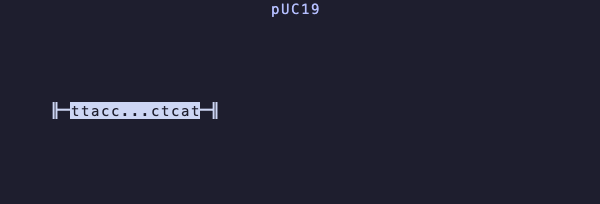

In [7]:
# bla occupies complement(1626..2486) in GenBank 1-based coords
# = 0-based half-open [1625, 2486)
BLA_START = 1625
BLA_END   = 2486

bla_wt = sg_wt.subgraph("bla_wt", BLA_START, BLA_END)
print(f"WT bla subgraph: {bla_wt.name!r}")

w_bla_wt = bla_wt.plot()
w_bla_wt

Mutant bla subgraph: 'pUC19'Derive subgraph succeeded.




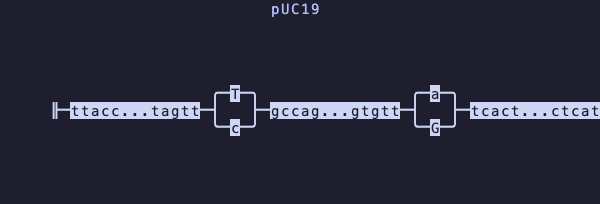

In [8]:
bla_seq = sg_seq.subgraph("bla_sequenced", BLA_START, BLA_END)
print(f"Mutant bla subgraph: {bla_seq.name!r}")

w_bla_seq = bla_seq.plot()
w_bla_seq

The two subgraph widgets both show the 861 bp bla locus.  The wild-type is a
single path; the mutant widget shows **two branch points** — one for C1904T
and one for A2100G.  Both SNPs are visible in the DNA graph regardless of
whether they alter the amino-acid sequence.

## Translate bla to protein

`SequenceGraph.translate_annotation()` looks up the named annotation,
determines the strand and reading frame from the stored metadata, and returns a
new `SequenceGraph` whose nodes are amino-acid residues rather than
nucleotides. The protein graph is created as a new block group in the same
sample as the DNA graph it was translated from.

We call it on both the wild-type and the mutant pUC19 graphs.  Both graphs
share the same annotation (bla is defined on the wild-type accession and is
reachable from any sample in the same repository), so `translate_annotation()`
works identically on both.

In [9]:
protein_wt = sg_wt.translate_annotation(region=bla_ann)
print(f"WT protein graph: {protein_wt.name!r}  (sample: {protein_wt.sample_name!r})")

WT protein graph: 'bla (protein)'  (sample: 'wt')


In [10]:
protein_seq = sg_seq.translate_annotation(region=bla_ann)
print(f"Mutant protein graph: {protein_seq.name!r}  (sample: {protein_seq.sample_name!r})")

Mutant protein graph: 'bla (protein)'  (sample: 'sequenced')


## Compare protein graphs

Both protein graphs contain the 286-residue TEM-1 β-lactamase (287 codons
minus the signal-peptide cleavage product).  Plot them and inspect:

- The **wild-type protein** is a single linear path ending in a stop codon.
- The **mutant protein** shows exactly **one branch point** — at residue 195 —
  corresponding to the E→K missense change.  The synonymous D129D substitution
  (from A2100G in the DNA) does not alter the path through the protein graph at
  all: it is invisible here.

This demonstrates the core value of translation: the protein graph filters out
silent variation and exposes only the changes that matter for the gene product.


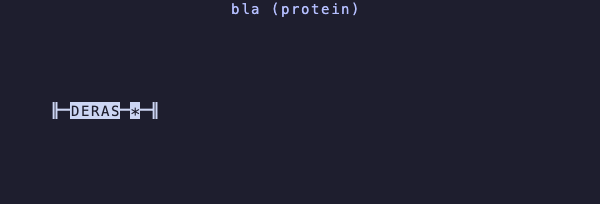

In [11]:
w_protein_wt = protein_wt.plot()
w_protein_wt


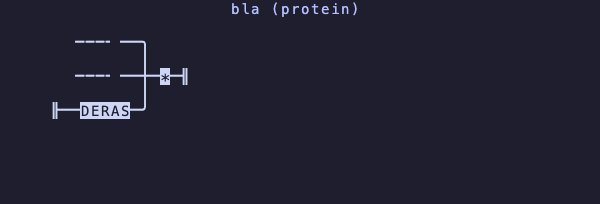

In [12]:
w_protein_seq = protein_seq.plot()
w_protein_seq

## Summary

| Sample | DNA variants in bla | Protein variants |
|--------|--------------------|-----------------|
| `wt`   | 0                  | 0               |
| `sequenced` | 2 (C1904T, A2100G) | 1 (E195K)  |

Key takeaways:

- `SequenceGraph.translate_annotation(region="bla")` uses the stored annotation
  to determine strand and coordinates automatically — no manual reverse-complement
  arithmetic required.
- The returned protein graph is a first-class `SequenceGraph`: it supports
  `.plot()`, `.list_annotations()`, `.export_fasta()`, and all other graph
  operations.
- The protein graph lands in the same sample as the DNA graph it came from —
  `protein_wt` in `wt`, `protein_seq` in `sequenced` — as a separate block group
  rather than a separate sample.
- Synonymous variants in the DNA are **not** represented in the protein graph;
  only amino-acid-changing variants create branches.
- Both the wild-type and mutant protein graphs live in the same repository, so
  further operations (alignment, library expansion, downstream annotation) can
  operate on them together.